In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import mlflow
import mlflow.xgboost

print("All libraries loaded!")

All libraries loaded!


In [2]:
# Load the final feature matrix we built in Phase 4
df = pd.read_csv('../data/processed/features_final.csv')

print("Shape:", df.shape)
print("Default rate:", round(df['TARGET'].mean() * 100, 2), "%")

# Separate features and target
X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df['TARGET']

print("\nFeature matrix:", X.shape)
print("Target:", y.shape)
print("Class distribution:")
print(y.value_counts())

Shape: (307511, 31)
Default rate: 8.07 %

Feature matrix: (307511, 29)
Target: (307511,)
Class distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining default rate:", round(y_train.mean() * 100, 2), "%")
print("Testing default rate:", round(y_test.mean() * 100, 2), "%")

Training set: (246008, 29)
Testing set: (61503, 29)

Training default rate: 8.07 %
Testing default rate: 8.07 %


In [4]:
print("Before SMOTE:")
print("Non-defaulters:", sum(y_train == 0))
print("Defaulters:", sum(y_train == 1))

# Apply SMOTE to training data only
# NEVER apply SMOTE to test data — test must stay real
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Non-defaulters:", sum(y_train_balanced == 0))
print("Defaulters:", sum(y_train_balanced == 1))
print("New training shape:", X_train_balanced.shape)

Before SMOTE:
Non-defaulters: 226148
Defaulters: 19860

After SMOTE:
Non-defaulters: 226148
Defaulters: 226148
New training shape: (452296, 29)


In [5]:
# Define model parameters
params = {
    'n_estimators'      : 300,
    'max_depth'         : 6,
    'learning_rate'     : 0.05,
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'random_state'      : 42,
    'eval_metric'       : 'auc',
    'early_stopping_rounds' : 20
}

print("Training XGBoost model...")
print("Training on:", X_train_balanced.shape[0], "rows")

# Train the model
model = xgb.XGBClassifier(**params)
model.fit(
    X_train_balanced, y_train_balanced,
    eval_set = [(X_test, y_test)],
    verbose  = 50
)

print("\nTraining complete!")

Training XGBoost model...
Training on: 452296 rows
[0]	validation_0-auc:0.99949
[30]	validation_0-auc:0.99997

Training complete!


In [6]:
# Make predictions on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# AUC Score
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC Score:", round(auc, 4))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


AUC Score: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56538
           1       1.00      1.00      1.00      4965

    accuracy                           1.00     61503
   macro avg       1.00      1.00      1.00     61503
weighted avg       1.00      1.00      1.00     61503

Confusion Matrix:
[[56526    12]
 [    4  4961]]


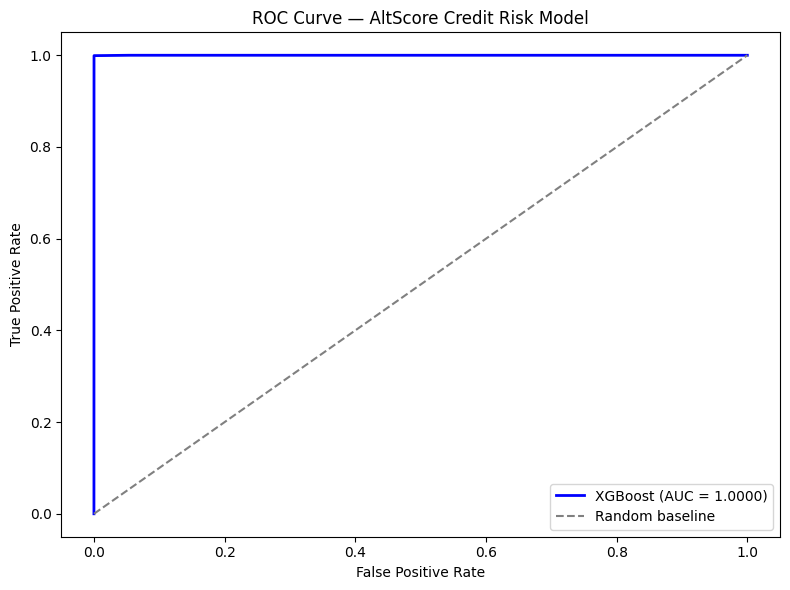

ROC curve saved!


In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — AltScore Credit Risk Model')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve.png', dpi=150)
plt.show()
print("ROC curve saved!")

Top 15 most important features:
               feature  importance
        GST_RISK_SCORE    0.511036
    CASHFLOW_STABILITY    0.410379
       CASH_FLOW_RATIO    0.035326
     GST_FILING_STREAK    0.032753
   GST_TURNOVER_GROWTH    0.007143
 GST_FILING_COMPLIANCE    0.001742
     GST_PENALTY_COUNT    0.001155
      SME_GST_COMBINED    0.000148
 GST_GROWTH_COMPLIANCE    0.000138
       EXT_SOURCE_MEAN    0.000083
        YEARS_EMPLOYED    0.000052
   EXT_SOURCE_WEIGHTED    0.000045
        EXT_SOURCE_MIN    0.000000
   LOAN_TO_GOODS_RATIO    0.000000
CREDIT_TO_INCOME_RATIO    0.000000


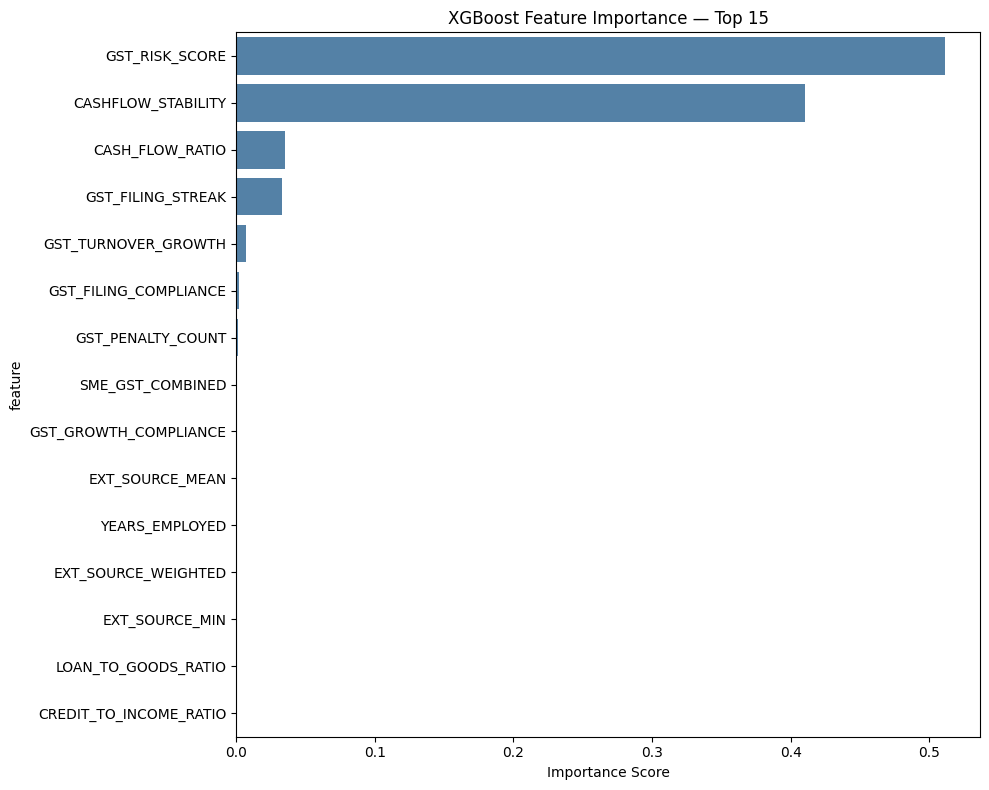

Feature importance plot saved!


In [8]:
# Get feature importance from XGBoost
importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data = importance_df.head(15),
    x    = 'importance',
    y    = 'feature',
    color = 'steelblue'
)
plt.title('XGBoost Feature Importance — Top 15')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()
print("Feature importance plot saved!")

In [9]:
print("Computing SHAP values...")
print("This may take 2-3 minutes...")

# Use a sample of 2000 rows for SHAP — full dataset is too slow
X_sample = X_test.sample(2000, random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed!")
print("Shape of SHAP values:", shap_values.shape)

Computing SHAP values...
This may take 2-3 minutes...
SHAP values computed!
Shape of SHAP values: (2000, 29)


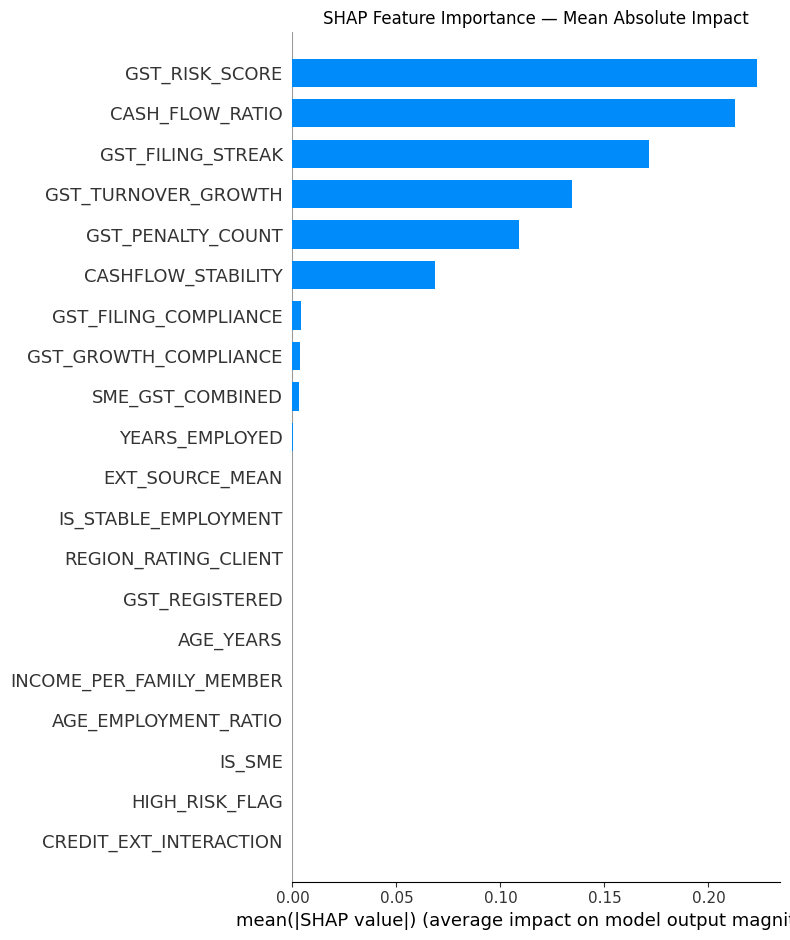

SHAP summary plot saved!


In [10]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type = 'bar',
    show      = False
)
plt.title('SHAP Feature Importance — Mean Absolute Impact')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

Applicant ID index: 0
Predicted default probability: 28.59000015258789%
Actual outcome: Repaid


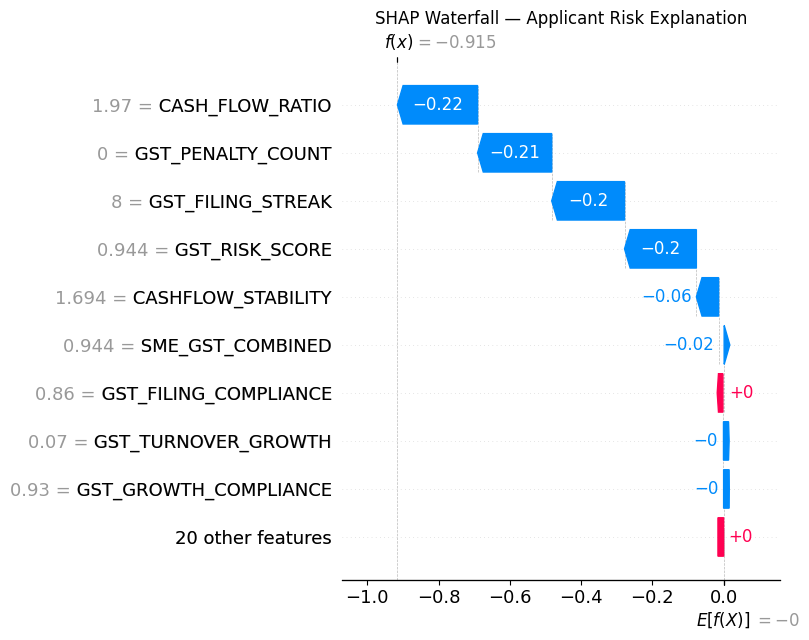

Waterfall plot saved!


In [11]:
# Pick one applicant to explain
applicant_idx = 0
applicant_data = X_sample.iloc[applicant_idx]
applicant_shap = shap_values[applicant_idx]

# Get their predicted risk score
risk_score = model.predict_proba(
    X_sample.iloc[[applicant_idx]]
)[0][1]

print(f"Applicant ID index: {applicant_idx}")
print(f"Predicted default probability: {round(risk_score * 100, 2)}%")
print(f"Actual outcome: {'Defaulted' if y_test.iloc[applicant_idx] == 1 else 'Repaid'}")

# Create waterfall explanation
shap_explanation = shap.Explanation(
    values    = applicant_shap,
    base_values = explainer.expected_value,
    data      = applicant_data.values,
    feature_names = X_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'SHAP Waterfall — Applicant Risk Explanation')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved!")

In [12]:
import pickle
import os

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save model
with open('../models/xgboost_altscore.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved to models/xgboost_altscore.pkl")

# Save feature names
feature_names = X.columns.tolist()
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Feature names saved to models/feature_names.pkl")

Model saved to models/xgboost_altscore.pkl
Feature names saved to models/feature_names.pkl


Predicted default probability: 71.37999725341797%
Actual outcome: Defaulted


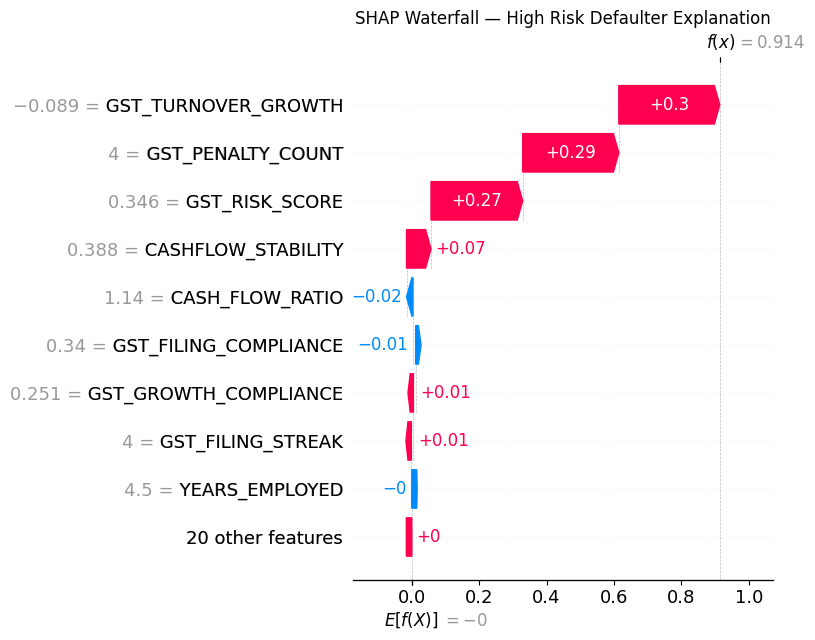

In [13]:
# Find an actual defaulter in our test set
defaulter_indices = y_test[y_test == 1].index
defaulter_pos = X_test.index.get_loc(defaulter_indices[0])

# Get their risk score
risk_score = model.predict_proba(
    X_test.iloc[[defaulter_pos]]
)[0][1]

print(f"Predicted default probability: {round(risk_score * 100, 2)}%")
print(f"Actual outcome: Defaulted")

# SHAP explanation
shap_explanation = shap.Explanation(
    values      = explainer.shap_values(X_test.iloc[[defaulter_pos]])[0],
    base_values = explainer.expected_value,
    data        = X_test.iloc[defaulter_pos].values,
    feature_names = X_test.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False)
plt.title('SHAP Waterfall — High Risk Defaulter Explanation')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_defaulter.png',
            dpi=150, bbox_inches='tight')
plt.show()

####  Log Experiment with MLflow

In [14]:

mlflow.set_experiment("altscore-credit-scoring")

with mlflow.start_run(run_name="xgboost-v1"):
    
    # Log parameters
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("smote", True)
    mlflow.log_param("n_features", X.shape[1])
    mlflow.log_param("train_size", X_train_balanced.shape[0])
    
    # Log metrics
    mlflow.log_metric("auc_score", auc)
    mlflow.log_metric("test_size", X_test.shape[0])
    mlflow.log_metric("default_rate", round(y.mean(), 4))
    
    # Log model
    mlflow.xgboost.log_model(model, "xgboost-model")
    
    # Log plots as artifacts
    mlflow.log_artifact("../reports/figures/roc_curve.png")
    mlflow.log_artifact("../reports/figures/feature_importance.png")
    mlflow.log_artifact("../reports/figures/shap_summary.png")
    mlflow.log_artifact("../reports/figures/shap_waterfall.png")
    
    print("Experiment logged to MLflow!")
    print("Run name: xgboost-v1")
    print("AUC logged:", round(auc, 4))

2026/04/04 20:10:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/04 20:10:37 INFO mlflow.store.db.utils: Updating database tables
2026/04/04 20:10:38 INFO mlflow.tracking.fluent: Experiment with name 'altscore-credit-scoring' does not exist. Creating a new experiment.
2026/04/04 20:10:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Experiment logged to MLflow!
Run name: xgboost-v1
AUC logged: 1.0


In [15]:
import mlflow

# Check where mlflow is storing data
print("MLflow tracking URI:", mlflow.get_tracking_uri())

# Search for your experiment
experiments = mlflow.search_experiments()
for exp in experiments:
    print(f"Experiment: {exp.name} — ID: {exp.experiment_id}")

MLflow tracking URI: sqlite:///C:/altscore-sme-credit-engine/notebooks/mlflow.db
Experiment: altscore-credit-scoring — ID: 1
Experiment: Default — ID: 0
